In [110]:
import pickle
import numpy as np
import pandas as pd
import re

def extract_agents_and_delta(filename):
    # matches "06APR_agents2_delta05.pkl" → (2, 5)
    match = re.search(r'agents(\d+)_delta(\d+)\.pkl', filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def results_to_df(results, agents, delta):
    rows = []
    for name, s in results.items():
        sf = s.silent_failure_rate_given_failure
        rows.append({
            "min_agents":      agents,
            "delta":           delta / 100,  # store as float e.g. 0.05
            "success":         s.task_success_rate,
            "time_to_success": s.mean_time_to_success,
            "silent_fail":     sf if not np.isnan(sf) else np.nan,
            "jsd":             s.mean_final_jsd,
            "alignment":       s.mean_final_alignment,
            "msgs":            s.mean_messages_sent,
            "apb":             s.mean_alignment_per_byte * 1e6
                               if s.mean_alignment_per_byte and
                               not np.isnan(s.mean_alignment_per_byte)
                               else np.nan,
        })
    return pd.DataFrame(rows)

# --- Build file list dynamically ---
thresholds = [0, 5, 10, 15, 20, 25, 30, 35, 40]
agent_levels = [2, 3, 4]

files = [
    f"09APR_agents{n}_delta{t:02d}.pkl"
    for n in agent_levels
    for t in thresholds
]

# --- Load all files ---
all_dfs = []
for fname in files:
    agents, delta = extract_agents_and_delta(fname)
    with open(fname, "rb") as f:
        results = pickle.load(f)
    df_tmp = results_to_df(results, agents, delta)
    all_dfs.append(df_tmp)

df = pd.concat(all_dfs, ignore_index=True)


df["apb_scaled"] = df["apb"] * 1e6
df.head(20)

,min_agents,delta,success,time_to_success,silent_fail,jsd,alignment,msgs,apb,apb_scaled
0,2,0.00,0.617,84.565640,1.000000,0.006132,0.630504,1552.728,11.601767,1.160177e+07
1,2,0.05,0.641,86.035881,0.651811,0.033830,0.648390,47.910,386.671423,3.866714e+08
2,2,0.10,0.675,85.454815,0.261538,0.037465,0.670001,29.415,650.786500,6.507865e+08
3,2,0.15,0.650,88.926154,0.111429,0.045627,0.649336,23.358,794.265200,7.942652e+08
4,2,0.20,0.705,89.865248,0.074576,0.044893,0.702191,20.301,988.256591,9.882566e+08
5,2,0.25,0.730,91.020548,0.037037,0.043693,0.715988,19.473,1050.521232,1.050521e+09
6,2,0.30,0.716,93.680168,0.077465,0.046882,0.712859,18.183,1120.134297,1.120134e+09
7,2,0.35,0.781,94.005122,0.105023,0.038677,0.776574,18.045,1229.583623,1.229584e+09
8,2,0.40,0.756,93.771164,0.094262,0.046429,0.752553,16.869,1274.610822,1.274611e+09
9,3,0.00,0.646,92.187307,1.000000,0.005665,0.672017,1571.988,12.214150,1.221415e+07


In [111]:
avg_df = (
    df.groupby("delta")
    .agg(
        success=("success", "mean"),
        time_to_success=("time_to_success", "mean"),
        silent_fail=("silent_fail", "mean"),
        jsd=("jsd", "mean"),
        alignment=("alignment", "mean"),
        msgs=("msgs", "mean"),
        apb=("apb", "mean"),
    )
    .round(4)
    .reset_index()
)

avg_df.head(10)

,delta,success,time_to_success,silent_fail,jsd,alignment,msgs,apb
0,0.00,0.6293,93.6563,1.0000,0.0059,0.6572,1604.612,11.7111
1,0.05,0.6153,96.9358,0.6312,0.0351,0.6355,51.283,355.1716
2,0.10,0.6533,96.2831,0.2646,0.0385,0.6695,32.437,592.7446
3,0.15,0.6580,98.8695,0.1319,0.0421,0.6796,25.821,753.9524
4,0.20,0.6953,101.4630,0.0885,0.0446,0.7108,22.866,893.4594
5,0.25,0.7200,102.8477,0.1099,0.0412,0.7400,22.373,951.3719
6,0.30,0.7260,102.1621,0.1467,0.0413,0.7534,21.282,1018.8660
7,0.35,0.7553,104.3853,0.1904,0.0381,0.7897,20.756,1095.8465
8,0.40,0.7380,104.1095,0.1853,0.0441,0.7756,19.167,1164.6744


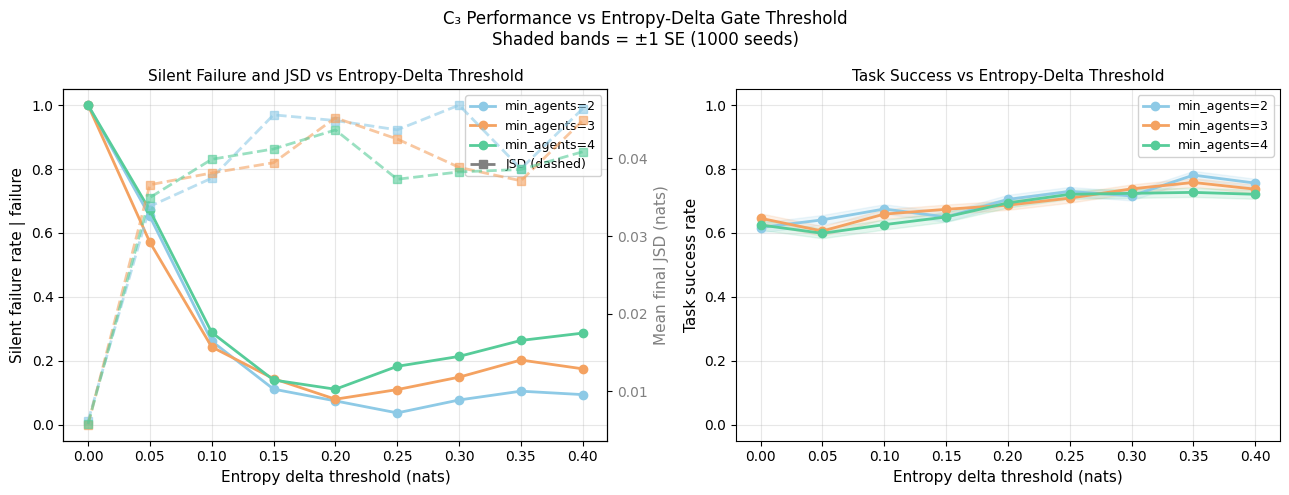

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate by min_agents and delta
plot_df = (
    df.groupby(["min_agents", "delta"])
    .agg(
        success=("success", "mean"),
        silent_fail=("silent_fail", "mean"),
        jsd=("jsd", "mean"),
        msgs=("msgs", "mean"),
    )
    .reset_index()
)

agent_levels = [ 2, 3, 4]
agent_colors = {2: "#8ecae6", 3: "#f4a261", 4: "#57cc99"}
agent_labels = {2: "min_agents=2", 3: "min_agents=3", 4: "min_agents=4"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---------------------------------------------------------------------------
# Left: Silent Failure (y1) and JSD (y2) vs Delta
# ---------------------------------------------------------------------------
ax1 = axes[0]
ax2 = ax1.twinx()

for n in agent_levels:
    sub = plot_df[plot_df["min_agents"] == n].sort_values("delta")
    ax1.plot(sub["delta"], sub["silent_fail"],
             color=agent_colors[n], linewidth=2,
             marker="o", markersize=6,
             label=agent_labels[n])
    ax2.plot(sub["delta"], sub["jsd"],
             color=agent_colors[n], linewidth=2,
             marker="s", markersize=6,
             linestyle="--", alpha=0.6)

ax1.set_xlabel("Entropy delta threshold (nats)", fontsize=11)
ax1.set_ylabel("Silent failure rate | failure", fontsize=11, color="black")
ax2.set_ylabel("Mean final JSD (nats)", fontsize=11, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax1.set_ylim(-0.05, 1.05)
ax1.set_title("Silent Failure and JSD vs Entropy-Delta Threshold", fontsize=11)
ax1.grid(True, alpha=0.3)

# Legend: agent levels for solid lines (silent fail)
# Add note that dashed = JSD
sf_handles = [
    plt.Line2D([0],[0], color=agent_colors[n], linewidth=2,
               marker="o", markersize=6, label=agent_labels[n])
    for n in agent_levels
]
jsd_handle = plt.Line2D([0],[0], color="gray", linewidth=2,
                         marker="s", markersize=6, linestyle="--",
                         label="JSD (dashed)")
ax1.legend(handles=sf_handles + [jsd_handle], fontsize=9, framealpha=0.9)

# ---------------------------------------------------------------------------
# Right: Success vs Delta
# ---------------------------------------------------------------------------
ax3 = axes[1]

for n in agent_levels:
    sub = plot_df[plot_df["min_agents"] == n].sort_values("delta")
    se  = np.sqrt(sub["success"] * (1 - sub["success"]) / 1000)
    ax3.plot(sub["delta"], sub["success"],
             color=agent_colors[n], linewidth=2,
             marker="o", markersize=6,
             label=agent_labels[n])
    ax3.fill_between(sub["delta"],
                     sub["success"] - se,
                     sub["success"] + se,
                     color=agent_colors[n], alpha=0.15)

ax3.set_xlabel("Entropy delta threshold (nats)", fontsize=11)
ax3.set_ylabel("Task success rate", fontsize=11)
ax3.set_ylim(-0.05, 1.05)
ax3.set_title("Task Success vs Entropy-Delta Threshold", fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9, framealpha=0.9)

fig.suptitle("C₃ Performance vs Entropy-Delta Gate Threshold\n"
             "Shaded bands = ±1 SE (1000 seeds)",
             fontsize=12)
fig.tight_layout()
plt.savefig("fig_delta_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

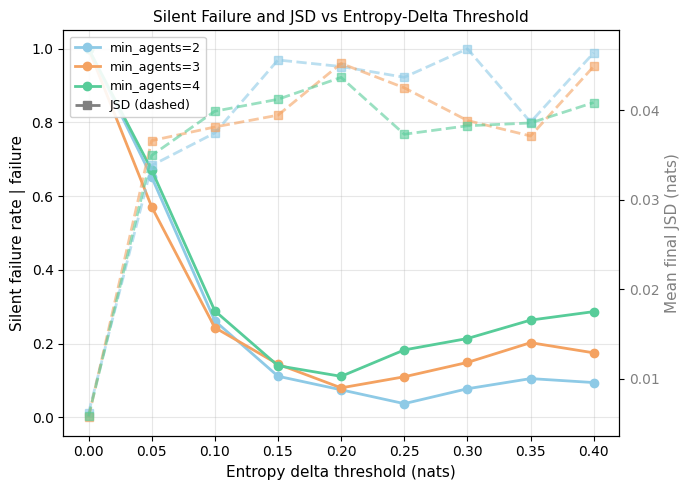

In [114]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = (
    df.groupby(["min_agents", "delta"])
    .agg(
        success=("success", "mean"),
        silent_fail=("silent_fail", "mean"),
        jsd=("jsd", "mean"),
        msgs=("msgs", "mean"),
    )
    .reset_index()
)

agent_levels = [2, 3, 4]
agent_colors = {2: "#8ecae6", 3: "#f4a261", 4: "#57cc99"}
agent_labels = {2: "min_agents=2", 3: "min_agents=3", 4: "min_agents=4"}

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

for n in agent_levels:
    sub = plot_df[plot_df["min_agents"] == n].sort_values("delta")
    ax1.plot(sub["delta"], sub["silent_fail"],
             color=agent_colors[n], linewidth=2,
             marker="o", markersize=6,
             label=agent_labels[n])
    ax2.plot(sub["delta"], sub["jsd"],
             color=agent_colors[n], linewidth=2,
             marker="s", markersize=6,
             linestyle="--", alpha=0.6)

ax1.set_xlabel("Entropy delta threshold (nats)", fontsize=11)
ax1.set_ylabel("Silent failure rate | failure", fontsize=11, color="black")
ax2.set_ylabel("Mean final JSD (nats)", fontsize=11, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax1.set_ylim(-0.05, 1.05)
ax1.set_title("Silent Failure and JSD vs Entropy-Delta Threshold", fontsize=11)
ax1.grid(True, alpha=0.3)

sf_handles = [
    plt.Line2D([0],[0], color=agent_colors[n], linewidth=2,
               marker="o", markersize=6, label=agent_labels[n])
    for n in agent_levels
]
jsd_handle = plt.Line2D([0],[0], color="gray", linewidth=2,
                          marker="s", markersize=6, linestyle="--",
                          label="JSD (dashed)")
ax1.legend(handles=sf_handles + [jsd_handle], fontsize=9, framealpha=0.9, loc="upper left")

fig.tight_layout()
plt.savefig("fig_delta_sweep.png")
plt.show()

In [83]:
plot_df = (
    df.groupby(["delta", "comm"])
      .agg(
          success=("success", "mean"),
          silent_fail=("silent_fail", "mean"),
      )
      .reset_index()
)

KeyError: 'comm'

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for comm in plot_df["comm"].unique():
    subset = plot_df[plot_df["comm"] == comm]
    subset = subset.sort_values("delta")
    
    plt.plot(subset["delta"], subset["success"], marker='o', label=comm)

plt.xlabel("Delta")
plt.ylabel("Success Rate")
plt.title("Success vs Delta by Communication Type")
plt.legend()
plt.grid()

plt.show()

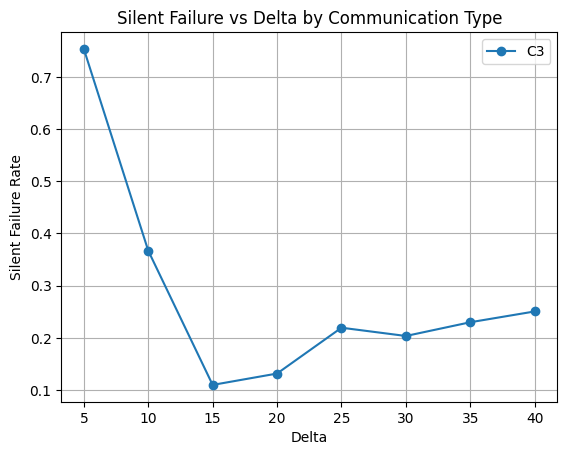

In [75]:
plt.figure()

for comm in plot_df["comm"].unique():
    subset = plot_df[plot_df["comm"] == comm]
    subset = subset.sort_values("delta")
    
    plt.plot(subset["delta"], subset["silent_fail"], marker='o', label=comm)

plt.xlabel("Delta")
plt.ylabel("Silent Failure Rate")
plt.title("Silent Failure vs Delta by Communication Type")
plt.legend()
plt.grid()

plt.show()

In [76]:
plot_df = (
    df.groupby(["delta", "comm"])
      .agg(
          success=("success", "mean"),
          silent_fail=("silent_fail", "mean"),
          jsd=("jsd", "mean"),
      )
      .reset_index()
)

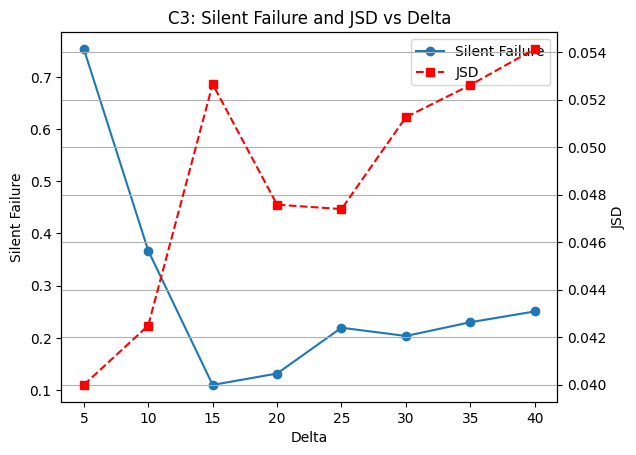

In [77]:
import matplotlib.pyplot as plt

for comm in plot_df["comm"].unique():
    subset = plot_df[plot_df["comm"] == comm].sort_values("delta")

    fig, ax1 = plt.subplots()

    # Silent failure (left axis)
    ax1.plot(subset["delta"], subset["silent_fail"], marker='o', label="Silent Failure")
    ax1.set_xlabel("Delta")
    ax1.set_ylabel("Silent Failure")

    # JSD (right axis)
    ax2 = ax1.twinx()
    ax2.plot(subset["delta"], subset["jsd"], marker='s', linestyle='--', color = 'red', label="JSD")
    ax2.set_ylabel("JSD")

    plt.title(f"{comm}: Silent Failure and JSD vs Delta")

    # Combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.grid()
    plt.show()

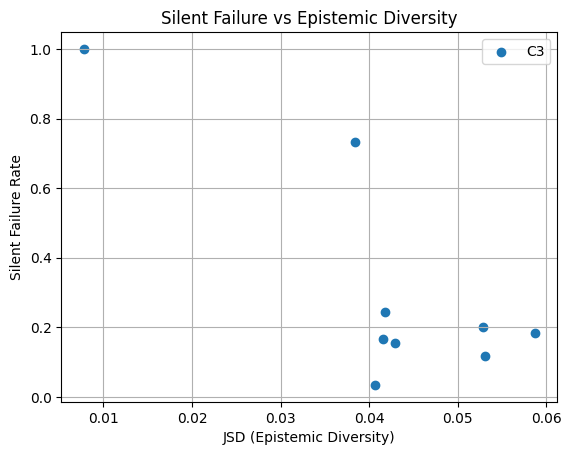

In [64]:
plt.figure()

for comm in plot_df["comm"].unique():
    subset = plot_df[plot_df["comm"] == comm]
    plt.scatter(subset["jsd"], subset["silent_fail"], label=comm)

plt.xlabel("JSD (Epistemic Diversity)")
plt.ylabel("Silent Failure Rate")
plt.title("Silent Failure vs Epistemic Diversity")
plt.legend()
plt.grid()

plt.show()

In [88]:
plot_df = (
    df.groupby(["delta", "comm"])
      .agg(
          success=("success", "mean"),
          silent_fail=("silent_fail", "mean"),
          jsd=("jsd", "mean"),
          msgs=("msgs", "mean"),
      )
      .reset_index()
)

import matplotlib.pyplot as plt

plt.figure()

for comm in plot_df["comm"].unique():
    subset = plot_df[plot_df["comm"] == comm].sort_values("delta")
    plt.plot(subset["msgs"], subset["success"], marker="o", label=comm)

    # optional: annotate each point with delta
    for _, row in subset.iterrows():
        plt.annotate(
            str(int(row["delta"])),
            (row["msgs"], row["success"]),
            textcoords="offset points",
            xytext=(4, 4)
        )

plt.xlabel("Mean Messages Sent")
plt.ylabel("Success Rate")
plt.title("Success vs Messages by Communication Type")
plt.legend()
plt.grid()
plt.show()

KeyError: 'comm'